#### 0. Install dependencies

In [1]:
import os
import h5py
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from copy import deepcopy

from gtda.plotting import plot_point_cloud, plot_diagram
from gudhi import AlphaComplex
from gtda.plotting import plot_diagram

import pickle
from pathlib import Path

#### 1. Load dataset

In [ ]:
!kaggle datasets download -d daavoo/3d-mnist
# Unpack into ./data/MNIST3d/ and delete

#### 2. Plot

In [2]:
samples = {}
train_file = "./data/MNIST3d/train_point_clouds.h5"

with h5py.File(train_file,"r") as hf:
  for key in hf.keys(): # key = id
    group = hf[key]
    label = int(group.attrs["label"])

    if (label not in samples):  # take 1 instance of each digit
      points = group["points"][:] # (N, 3)  x, y, z
      samples[label] = points

      if len(samples) == 10:
        break


In [3]:
# sorting is optional i just think it looks better this way
sorted_samples = dict(sorted(samples.items()))
plot_point_cloud(sorted_samples[5]) # change number in brackets to plot different digits

#### 3. Normalization
all point clouds should already be normalised according to dataset documentation. lets check that

In [4]:
stats = {
    "num_points": [],
    "range_x": [],
    "range_y": [],
    "range_z": [],
}

In [5]:
with h5py.File(train_file, "r") as hf:
    print(f'Total number of samples: {len(list(hf.keys()))}')
    for key in list(hf.keys()): # iterate over all samples
        points = hf[key]["points"][:] # (N, 3)

        # bounding box
        mins = points.min(axis=0)
        maxs = points.max(axis=0)
        ranges = maxs - mins  # [range_x, range_y, range_z]

        stats["num_points"].append(len(points))

        # axiswize ranges
        stats["range_x"].append(ranges[0])
        stats["range_y"].append(ranges[1])
        stats["range_z"].append(ranges[2])

Total number of samples: 5000


In [6]:
for k in stats:
    arr = np.array(stats[k])
    print(f"{k:15s} | mean = {arr.mean():.4f} ± {arr.std():.4f} | "
          f"min = {arr.min():.4f} | max = {arr.max():.4f}")

num_points      | mean = 22600.0900 ± 4894.9959 | min = 9250.0000 | max = 38200.0000
range_x         | mean = 0.3000 ± 0.0003 | min = 0.3000 | max = 0.3158
range_y         | mean = 0.7915 ± 0.1899 | min = 0.1500 | max = 1.0000
range_z         | mean = 0.9859 ± 0.0509 | min = 0.5000 | max = 1.0000


In [7]:
# subsample the original dataset

def subsample_dataset(max_samples_per_class=10):
  point_clouds = []
  labels = []

  with h5py.File(train_file, "r") as hf:
      for key in hf.keys(): # indices
          group = hf[key] # point cloud
          label = int(group.attrs["label"]) # labels

          if sum(1 for l in labels if l == label) >= max_samples_per_class:
              continue

          points = group["points"][:].astype(np.float64)

          point_clouds.append(points)
          labels.append(label)

          if len(point_clouds) >= 10 * max_samples_per_class:
              break

  labels = np.array(labels)
  return point_clouds, labels

In [8]:
point_clouds = subsample_dataset(max_samples_per_class=50)[0]
labels = subsample_dataset(max_samples_per_class=50)[1]
max([cloud.shape[0] for cloud in point_clouds])

33800

point clouds contain way too many points so the simplicial complexes will not calculate in reasonable time. therefore we subsample the points

In [9]:
rng = np.random.default_rng(seed=42)

subsampled_point_clouds = []
n_points = 1000

point_clouds_to_subsample, lables_subsampled = subsample_dataset(1)

for pc in subsample_dataset(1)[0]:
    if pc.shape[0] <= n_points:
        subsampled_point_clouds.append(pc)
    else:
        idx = rng.choice(pc.shape[0], n_points, replace=False)
        subsampled_point_clouds.append(pc[idx])
subsampled_point_clouds = np.array(subsampled_point_clouds)

plot_point_cloud(subsampled_point_clouds[0])

#### 4. Persistance diagrams

In [20]:
from joblib import Parallel, delayed
from tqdm import tqdm

In [18]:
def process_cloud(cloud, lifetime_thresh=1e-8, max_alpha_square=10):
    ac = AlphaComplex(points=cloud)

    st = ac.create_simplex_tree(
        max_alpha_square=max_alpha_square
    )

    persistence = st.persistence(homology_coeff_field=2)

    persistence = [
        (dim, pair)
        for (dim, pair) in persistence
        if np.isinf(pair[1]) or pair[1] - pair[0] > lifetime_thresh
    ]

    return st, persistence


def build_diagrams(
    point_clouds,
    lifetime_thresh=1e-8,
    max_alpha_square=10,
    n_jobs=-1
):

    trees = []
    diagrams = []

    results = Parallel(n_jobs=n_jobs)(
		delayed(process_cloud)(
        	cloud,
        	lifetime_thresh,
        	max_alpha_square
    	)
    	for cloud in tqdm(point_clouds, desc="Processing clouds")
	)

    trees, diagrams = zip(*results)

    return trees, diagrams

In [21]:
_, diagrams = build_diagrams(point_clouds)

trees_sub, diagrams_sub = build_diagrams(subsampled_point_clouds)
_, del_diagrams = build_diagrams(subsampled_point_clouds, max_alpha_square=np.infty)

Processing clouds: 100%|██████████| 10/10 [00:00<?, ?it/s]


#### 5. Save/load diagrams

In [22]:
trees_path = Path("./data/tda/simplex_trees_gudhi.pkl")
diagrams_path = Path("./data/tda/persistence_diagrams_gudhi.pkl")

subsampled_trees_path = Path("./data/tda/subsampled_simplex_trees_gudhi.pkl")
subsampled_diagrams_path = Path("./data/tda/subsampled_persistence_diagrams_gudhi.pkl")

delaunay_diagrams_path = Path("./data/tda/delaunay_persistence_diagrams_gudhi.pkl")

In [23]:
def save_tree_diagram(diagrams_path, diagrams, trees_path=None, trees=None):
  if(trees_path):
    with open(trees_path, "wb") as f:
      pickle.dump(trees, f)
    print(f"Trees saved to {trees_path}")

  with open(diagrams_path, "wb") as f:
    pickle.dump(diagrams, f)

  print(f"Diagrams saved to {diagrams_path}")

def load_object(path):
  with open(path, "rb") as f:
    loaded = pickle.load(f)

  print(f"Loaded {len(loaded)} objects")
  return loaded

In [24]:
save_tree_diagram(diagrams_path, diagrams)
save_tree_diagram(subsampled_diagrams_path, diagrams_sub, subsampled_trees_path, trees_sub)
save_tree_diagram(delaunay_diagrams_path, del_diagrams)

Diagrams saved to data\tda\persistence_diagrams_gudhi.pkl
Trees saved to data\tda\subsampled_simplex_trees_gudhi.pkl
Diagrams saved to data\tda\subsampled_persistence_diagrams_gudhi.pkl
Diagrams saved to data\tda\delaunay_persistence_diagrams_gudhi.pkl


In [25]:
diagrams_loaded = load_object(diagrams_path)
subsampled_diagrams_loaded = load_object(subsampled_diagrams_path)
delaunay_diagrams_loaded = load_object(delaunay_diagrams_path)

Loaded 500 objects
Loaded 10 objects
Loaded 10 objects


#### 6. Plot diagrams

In [26]:
import gudhi as gd
from matplotlib import pyplot as plt

def plot_persistance(diagrams, labels, digit):
  idx = np.where(labels == digit)[0][0]
  gd.plot_persistence_diagram(diagrams[idx], legend = True)
  plt.show()

c:\Users\kiril\OneDrive\Documents\Projects\topology-mnist3d\.venv\Lib\site-packages\gudhi\persistence_graphical_tools.py:150: UserWarning: usetex mode requires TeX.
  warnings.warn("usetex mode requires TeX.")


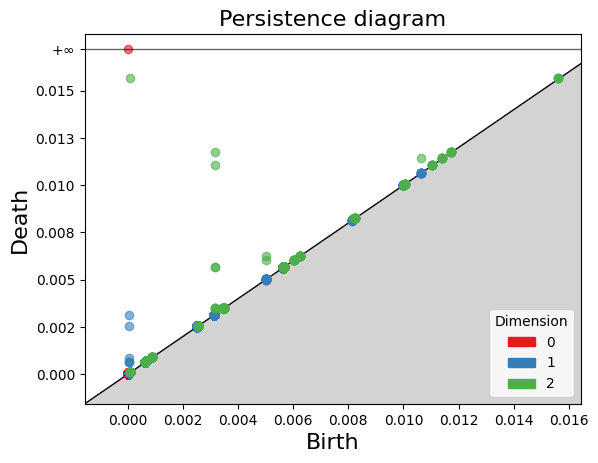

In [27]:
plot_persistance(diagrams_loaded, labels, 8)

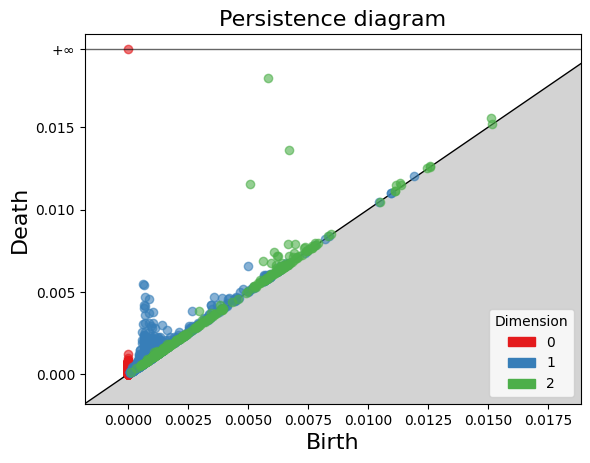

In [28]:
plot_persistance(subsampled_diagrams_loaded, lables_subsampled, 8)

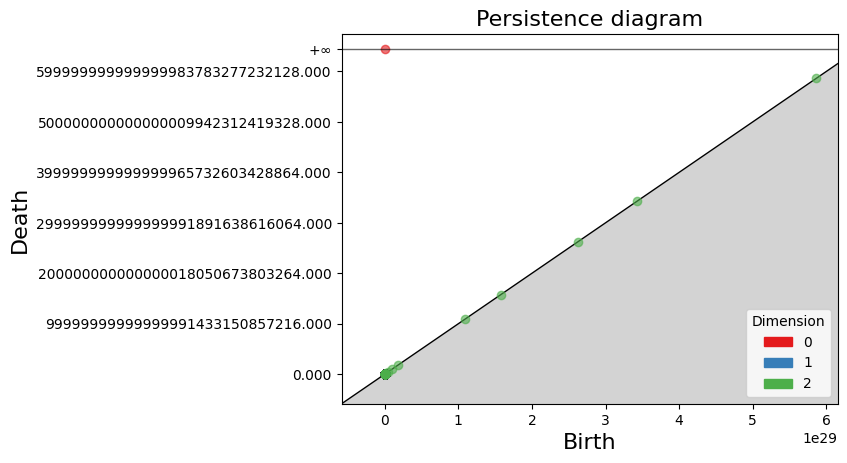

In [29]:
plot_persistance(delaunay_diagrams_loaded, lables_subsampled, 8)

#### 7. Vectorization

In [ ]:
subsampled_trees_loaded = load_object(subsampled_trees_path)